# 기각 해석
- 기각할 수 있을 때 (유의미한 결과)

    * 검정 결과, p값은 0.032로 유의수준 0.05 하에 귀무가설을 기각할 수 있다.
    * 이는 두 집단 간에 통계적으로 유의한 차이가 있음을 시사한다.
    * 따라서 두 집단의 평균은 통계적으로 유의미하게 다르다고 판단된다.

- 기각할 수 없을 때 (유의미하지 않음)

    * 검정 결과, p값은 0.082로 유의수준 0.05를 초과하므로 귀무가설을 기각할 수 없다.
    * 따라서 관측된 차이는 통계적으로 유의하지 않다고 말할 수 있다.

# 일표본 검정 : Y가 연속형 변수 ( 샘플이 하나)

### 가설 검정 
1. 모평균의 가설 검정 
    * H0 : mu = 어떤 값, H1 : mu != 어떤 값 (통상적으로 모평균이라고 알려져온 값)
2. 모비율의 가설 검정 
    * H0 : P = 어떤비율, H1 : P != 어떤 비율 (통상적으로 모비율이라고 알려져온 값)

## 1. Z 검정 
- 모집단의 분산을 아는 경우
- + 표본의 크기가 30 이상 
- 모분산을 알면 항상 z-검정이 원칙

## 2. T 검정 - 그냥 종속변수만 있는 경우
- 모집단의 분산을 모르는 경우 
- + 표본의 크기가 30미만
- 모분산을 모르면 항상 t-검정이 원칙

In [1]:
# 모표준편차를 아는 경우 : Z 검정 

# 모평균 추정 
import numpy as np

n = 36    # 표본 크기
x = 31100 # 표본 평균
sigma = 4500  # 모표준편차 

alpha = 0.05   # 신뢰수준 95% 기준 

from scipy.stats import norm 

SE = sigma/np.sqrt(n) # 표준오차 
conf_z = norm.ppf(1-alpha/2)  # Z_a/2 = 신뢰계수 (1.95)

ME = conf_z*SE   # 허용오차 

print("모평균 점추정량 : ", x)
print("신뢰수준 95% 하에 신뢰구간 : ({:.3f},{:.3f})".format(x-ME, x+ME) )
print(f"오차의 한계 : {ME:.3f}")

모평균 점추정량 :  31100
신뢰수준 95% 하에 신뢰구간 : (29630.027,32569.973)
오차의 한계 : 1469.973


In [2]:
# 오차의 한계로 표본 규모 
# 오차의 한계가 500 이하일 확률이 0.95가 되도록 모집단 평균의 추정치를 원하는 경우
# 표본 크기는 최소 얼마가 되어야 하는가?

sigma = 4500         # 모표준편차
ME = 500             # 허용 오차
alpha = 0.05         # 유의수준
z = norm.ppf(1 - alpha/2)  # 신뢰계수 (약 1.96)

# 필요한 표본 크기 계산
n_required = (z * sigma / ME) ** 2

n_required

311.1581644762241

한 도시의 평균 월급이 과거에는 ₩30,000이라 알려져 있다.  
그러나 최근 경제 변화 이후 월급이 변했다는 주장이 제기됨.  
이에 따라 36명을 표본 조사한 결과, 평균이 ₩31,100이었다.  
모표준편차는 ₩4,500이라고 알려져 있다고 가정하자.  
유의수준 0.05 하에서 이 주장이 통계적으로 유의미한지 검정하라.  

In [28]:
# 모평균에 대한 가설 검정, 모표준편차 알고있음 -> Z검정 
# H0 : mu = 30000, H1 : mu != 30000 (양측 검정)

x = 31100  # 표본평균 
n = 36     # 표본 크기 

sigma = 4500  # 모표준편차 
mu_0 = 30000. # 귀무가설 하 모평균 
alpha = 0.05  # 유의수준 

# Z 통계량 계산 
SE = sigma/np.sqrt(n)
z_stat = (x-mu_0)/SE

# 임계값 (양측 검정) : critical value
cv = norm.ppf(1 - alpha/2)

# p-value
pv = 2 * (1 - norm.cdf(abs(z_stat)))

print(f"Z 통계량 : {z_stat:.4f}")
print(f"임계값 : {cv:.4f}")
print(f"p-value : {pv:.4f}")
print(f"검정 결과, p-value 값은 {pv:.4f}로 유의수준 0.05보다 크므로 귀무가설을 기각할 수 없다.모평균은 30,000이라고 볼 수 있다 (차이 없음)")

Z 통계량 : 1.4667
임계값 : 1.9600
p-value : 0.1425
검정 결과, p-value 값은 0.1425로 유의수준 0.05보다 크므로 귀무가설을 기각할 수 없다.모평균은 30,000이라고 볼 수 있다 (차이 없음)


In [29]:
# 모평균에 대한 가설 검정, 모표준편차 알고있음 -> Z검정 
# H0 : mu = 30000, H1 : mu > 30000 (우측 단측 검정)

x = 31100  # 표본평균 
n = 36     # 표본 크기 

sigma = 4500  # 모표준편차 
mu_0 = 30000. # 귀무가설 하 모평균 
alpha = 0.05  # 유의수준 

# Z 통계량 계산 
SE = sigma/np.sqrt(n)
z_stat = (x-mu_0)/SE

# 임계값 (우측 검정)
cv = norm.ppf(1 - alpha)   # alpha/2 아님  / 좌측 : norm.ppf(alpha)

# p-value
pv = 1 - norm.cdf(abs(z_stat)) # X2 안함   / 좌측 : norm.cdf(abs(z_stat)) 

print(f"Z 통계량 : {z_stat:.4f}")
print(f"임계값 : {cv:.4f}")
print(f"p-value : {pv:.4f}")

Z 통계량 : 1.4667
임계값 : 1.6449
p-value : 0.0712


한 대학교의 학생들이 한 달 동안 지출하는 평균 식비를 조사하기 위해,  
무작위로 16명의 학생을 표본으로 선택하여 조사를 실시하였다.  
조사 결과, 이들 학생의 평균 식비는 ₩650이었고,  
표본의 표준편차는 ₩55로 나타났다.
  
모집단 식비의 분포가 정규분포를 따른다고 가정할 때,  
신뢰수준 95% 하에서 모평균에 대한 신뢰구간을 구하고,  
오차의 한계를 제시하라.  

In [34]:
## 모표준편차를 모르는 경우 -> t-test

# 모평균 추정 
x = 650   # 표본평균
n = 16    # 표본크기 
s = 55    # 표본표준편차 
alpha = 0.05  # 신뢰수준 95% 기준 
df = n-1      # 자유도 

from scipy.stats import t 
SE = s/np.sqrt(n)
conf_t = t.ppf(1 - alpha/2, df) # alpha/2, df 

ME = conf_t * SE

print("모평균 추정량 : ", x)
print("신뢰수준 95% 하에 신뢰구간 : ({:.3f},{:.3f})".format(x-ME, x+ME))
print(f"오차의 한계 : {ME:.3f}")

모평균 추정량 :  650
신뢰수준 95% 하에 신뢰구간 : (620.693,679.307)
오차의 한계 : 29.307


In [37]:
# 오차의 한계로 표본 규모 
# 오차의 한계가 20 이하일 확률이 0.95가 되도록 모집단 평균의 추정치를 원하는 경우
# 표본 크기는 최소 얼마가 되어야 하는가?

ME = 20             # 허용 오차
alpha = 0.05         # 유의수준
conf_t = t.ppf(1-alpha/2, df)  

# 필요한 표본 크기 계산
n_required = (conf_t**2 * s**2 / ME** 2)

n_required

31.457089178865132

In [40]:
# 모평균에 대한 가설 검정, 모표준편차 모르고 있음 -> T검정 
# H0 : mu = 600, H1 : mu != 600 (양측 검정)

x = 650  # 표본평균 
n = 16     # 표본 크기 
s = 55  # 모표준편차 
df = n-1 

mu_0 = 600  # 귀무가설 하 모평균 
alpha = 0.05  # 유의수준 

# 검정 통계량 계산 
SE = s/np.sqrt(n)
t_stat = (x-mu_0)/SE

# 임계값 (우측 검정)
cv = t.ppf(1 - alpha/2, df)   # alpha/2 

# p-value
pv = 2 * (1 - t.cdf(np.abs(t_stat), df)) # X2 , t_stat 절댓값

print(f"T 통계량 : {t_stat:.4f}")
print(f"임계값 : {cv:.4f}")
print(f"p-value : {pv:.4f}")

T 통계량 : 3.6364
임계값 : 2.1314
p-value : 0.0024


In [39]:
# 모평균에 대한 가설 검정, 모표준편차 모르고 있음 -> T검정 
# H0 : mu = 600, H1 : mu > 600 (우측 단측 검정)

x = 650  # 표본평균 
n = 16     # 표본 크기 
s = 55  # 모표준편차 
df = n-1 

mu_0 = 600  # 귀무가설 하 모평균 
alpha = 0.05  # 유의수준 

# 검정 통계량 계산 
SE = s/np.sqrt(n)
t_stat = (x-mu_0)/SE

# 임계값 (우측 검정)
cv = t.ppf(1 - alpha, df)   # alpha/2 아님 /   좌측 : t.ppf(alpha, df)

# p-value
pv = 1 - t.cdf(t_stat, df) # X2 안함      /   좌측 : t.cdf(t_stat, df)

print(f"T 통계량 : {t_stat:.4f}")
print(f"임계값 : {cv:.4f}")
print(f"p-value : {pv:.4f}")  # 귀무가설 기각하여 대립가설 채택 

T 통계량 : 3.6364
임계값 : 1.7531
p-value : 0.0012


# 모분산의 추정과 가설 검정 : 카이제곱 분포 

- 모평균을 모르는 경우 
- 모평균을 아는 경우

In [5]:
# 모평균 모르는 경우
n = 10  # 표본 크기 
v = 3.4 # 표본 분산 
df = n-1
alpha = 0.05 #신뢰수준 95%

from scipy.stats import chi2
chi2_c1 = chi2.ppf(1-alpha/2, df)
chi2_c2 = chi2.ppf(alpha/2, df)

print(f'점추정량 : {v}')
print(f"구간 추정량 : ({df*(v)/chi2_c1:.3f}),({df*(v)/chi2_c2:.3f})")

점추정량 : 3.4
구간 추정량 : (1.609),(11.332)


In [7]:
# 가설 검정 
# H0 : 표본분산 = 모분산, H1 : 표본분산 != 모분산 
 
n = 10  # 표본 크기 
v = 3.4 # 표본 분산 
df = n-1
alpha = 0.05 #신뢰수준 95%

v0 = 3.6 # 귀무가설 하 모분산

cstat = df * v/ v0 # 카이제곱 통계량

if chi2.cdf(cstat, df) < 0.5:
    pv = 2*(chi2.cdf(cstat, df))
    
else:
    pv = 2*(1-chi2.cdf(cstat, df))
        
# 임계값 (우측 검정)
chi2_c1 = chi2.ppf(alpha/2, df)
chi2_c2 = chi2.ppf(1-alpha/2, df)

print(f"검정통계량 : {cstat:.4f}")
print(f"임계값 : {chi2_c1:.4f},{chi2_c2:.4f}")
print(f"p-value : {pv:.4f}")

검정통계량 : 8.5000
임계값 : 2.7004,19.0228
p-value : 0.9693


In [9]:
# 가설 검정 
# H0 : 표본분산 = 모분산, H1 : 표본분산 < 모분산  (오른쪽 단측 검정)
 
n = 10  # 표본 크기 
v = 3.4 # 표본 분산 
df = n-1
alpha = 0.05 #신뢰수준 95%

v0 = 3.6 # 귀무가설 하 모분산

cstat = df * v/ v0 # 카이제곱 통계량

pv = 1- chi2.cdf(cstat, df) # 유의확률   / 좌 단측 검정 : chi2.cdf(cstat, df)

# 임계값 (우측 검정)
cv = chi2.ppf(1-alpha, df)           # / 좌 단측 검정 : chi2.ppf(alpha, df)  

print(f"검정통계량 : {cstat:.4f}")
print(f"임계값 : {cv:.4f}")
print(f"p-value : {pv:.4f}")

검정통계량 : 8.5000
임계값 : 16.9190
p-value : 0.4846


# 독립 표본 T 검정 : 독립변수 하나 (범주형 변수- 수준 2개) , 종속변수 하나(연속형 변수)
- 두 개의 서로 독립된 그룹 간 평균 차이가 유의미한지를 검정

1. (표본 크기 30이상)
- 모집단의 분산을 아는 경우 : Z 분포, 모분산 사용
- 모집단의 분산을 모르는 경우 : Z분포, 표본분산 사용(s)
2. (표본 크기 30 미만)
- 모집단의 분산을 모르지만 두 집단의 분산이 같다(등분산성)는 것 아는 경우 : t분포, 합동표본분산(Sp) 사용
- 모집단의 분산을 모르지만 두 집단의 분산이 다르다(이분산성)는 것 아는 경우 : t분포

# 표본 크기 30 미만
- 모집단의 분산이 동일한지 여부  (등분산성 여부)

In [17]:
from scipy.stats import ttest_ind
import pandas as pd

x = ['x1']*5 + ['x2']*4
y = [1,3,5,7,9,9,11,13,15]

df = pd.DataFrame({'x': x, 'y': y})
df

,x,y
0,x1,1
1,x1,3
2,x1,5
3,x1,7
4,x1,9
5,x2,9
6,x2,11
7,x2,13
8,x2,15


In [22]:
# equal_var : 모집단의 분산이 동일한지 여부 
x1 = df[df['x'] == 'x1']
x2 = df[df['x'] == 'x2']

# 등분산성 인 것을 알 때 
tstat, p = ttest_ind(x1['y'], x2['y'], equal_var = True, alternative = 'two-sided')
print(f"검정통계량 : {tstat:.3f}, 유의확률 : {p:.3f}")
# 귀무가설 기각 -> 두 집단의 평균이 차이가 있다.

검정통계량 : -3.564, 유의확률 : 0.009


In [25]:
# 등분산성인것을 모를 때
tstat, p = ttest_ind(x1['y'], x2['y'], equal_var = False, alternative = 'two-sided')
print(f"검정통계량 : {tstat:.3f}, 유의확률 : {p:.3f}")
# 귀무가설 기각 : 두 집단의 평균이 차이가 있다.

검정통계량 : -3.656, 유의확률 : 0.008


# 대응표본 T검정 : 단일 모집단에 어떤 처리를 가했을 때, 처리 전후(2가지)에 따른 평균의 차이를 비교

    •	학생들의 시험 전/후 점수 비교
	•	환자의 약 복용 전/후 혈압 비교
	•	동일 상품의 이전 가격과 할인 후 가격 비교

- 표본의 크기가 30 이상인 경우 : Z 분포 
- 표본의 크기가 30 미만인 경우 : T 분포 

In [28]:
import numpy as nnp

# 가상의 시험 전/후 점수
stds = ["std"+ str(i+1) for i in range(10)]
pre_scores = np.array([68, 70, 75, 73, 69, 72, 65, 74, 71, 70])
post_scores = np.array([72, 74, 78, 76, 71, 75, 67, 78, 74, 73])

df= pd.DataFrame({'students':stds, '시험전점수':pre_scores, '시험후점수':post_scores})
df

,students,시험전점수,시험후점수
0,std1,68,72
1,std2,70,74
2,std3,75,78
3,std4,73,76
4,std5,69,71
5,std6,72,75
6,std7,65,67
7,std8,74,78
8,std9,71,74
9,std10,70,73


In [29]:
from scipy.stats import ttest_rel  # 대응표본 -> rel 

tstat, p = ttest_rel(df['시험전점수'],df['시험후점수'], alternative = 'two-sided')
print(f"검정통계량 : {tstat:.3f}, 유의확률 : {p:.3f}")

# 귀무가설 기각 -> 두 시점의 평균 차이가 있다. (시험 전 점수와 시험 후 점수의 차이가 있다고 말할 수 있다.)

검정통계량 : -13.286, 유의확률 : 0.000


---
# ANOVA

# 분산분석 : 3개 이상의 집단의 모평균 차이를 검정 (독립변수 범주가 3개 이상, 종속변수:연속형) : F 검정 통계량 사용
- 3가지 가정을 만족해야함
    1. 각 표본의 반응변수(Y)는 정규분포여야한다.  - 검정 
    2. 모든 집단의 반응변수의 분산이 동일해야한다(등분산성) - 검정
    3. 각 관찰값은 독립적이어야한다.  - 검정 안함

In [67]:
#   일원 배치 분산분석 : 독립변수 1개(수준-3개 이상), 종속변수 1개(연속형)
#   이원배치 분산분석 : 독립변수 2개, 종속변수 1개(연속형)
#   multi-way ANOVA : 독립변수 3개 이상(수준 3개이상 1개이상), 종속변수 1개(연속형)
#   다변량 분산분석 : 종속변수가 2개 이상 (연속형)

# 가정 확인 

## 정규성 검정 : shpiro test, kstest, jarque_bera 
- 귀무가설 : 표본의 모집단이 정규 분포와 차이가 없다. (정규성 만족)
- 대립가설 : 표본의 모집단이 정규 분포와 차이가 있다. (정규성 불만족)
## 등분산 검정 : Barlett test(정규성 만족시), Levene test(정규성 만족 하지 않을 때)
- 귀무가설 : 집단 간 모분산에는 차이가 없다 (등분산 만족)
- 대립가설 : 집단 간 모분산이 모두 같다고 할 수 없다 (등분산 불만족)

In [97]:
from scipy.stats import norm
data = norm.rvs(size = 100, random_state = 0)  # 정규성을 만족하는 크기 100의 표본 생성 

In [104]:
# 정규성 검정 
from scipy.stats import shapiro, jarque_bera, kstest, zscore, probplot

# shapiro 
sstat,p = shapiro(data)
print(f"검정통계량 : {sstat:.3f}, 유의확률 : {p:.3f}")

검정통계량 : 0.993, 유의확률 : 0.869


In [105]:
# kstest(콜모고로프 스미르노프)
kstat, p = kstest(data, cdf=norm.cdf)
print(f"검정통계량 : {kstat:.3f}, 유의확률 : {p:.3f}")

검정통계량 : 0.058, 유의확률 : 0.867


In [106]:
# jarque_bera 
jstat, p = jarque_bera(data)
print(f"검정통계량 : {jstat:.3f}, 유의확률 : {p:.3f}")

검정통계량 : 0.597, 유의확률 : 0.742


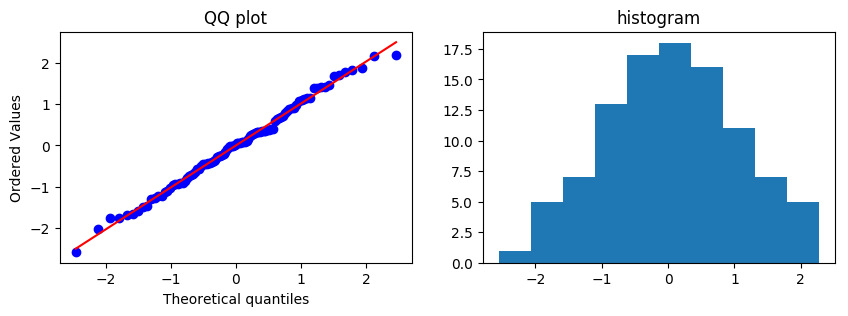

In [108]:
# QQ plot and histogram
import matplotlib.pyplot as plt
zdata = zscore(data)

fig, ax = plt.subplots(1,2,figsize = (10,3))

# QQ plot : 데이터들이 대각선에 붙어있을수록 정규성을 만족하는 것으로 본다.
(osm, odr),(slope, intercept, r) = probplot(zdata, plot = ax[0])
ax[0].set_title("QQ plot")

# histogram
ax[1].hist(data)
ax[1].set_title("histogram")
plt.show()

## 정규성 만족 시 -> 등분산성 검정 (Bartlett)

In [109]:
from scipy.stats import bartlett

data1 = norm.rvs(size = 50, random_state = 0)
data2 = norm.rvs(size = 50, random_state = 1)
data3 = norm.rvs(size = 50, random_state = 2)

bstat, p = bartlett(data1, data2, data3)
print(f"검정통계량 : {bstat:.3f}, 유의확률 : {p:.3f}")  # 귀무가설 채택하여 집단간 모분산에 차이가 없다.

검정통계량 : 1.082, 유의확률 : 0.582


## 정규성 만족 안할 시 -> 등분산성 검정 (Levene) 
- levene는 표본 샘플 개수가 달라도 같게 한다.

In [110]:
import pandas as pd

data= pd.DataFrame({'fac1':[48,54,57,54,62], 
                   'fac2':[73,63,66,64,74],
                   'fac3':[51,63,61,54,56]})

In [112]:
from scipy.stats import levene

lstat, p = levene(data['fac1'], data['fac2'], data['fac3'], center = 'mean')
print(f"검정통계량 : {lstat:.3f}, 유의확률 : {p:.3f}")  # 귀무가설 채택하여 집단간 모분산에 차이가 없다.

검정통계량 : 0.145, 유의확률 : 0.867


#### 검정 결과  k개의 집단 중에서 적어도 한 집단의 모평균이 다르다고 판단(대립가설 채택) 시
- -> 사후 검정 실행 (정확히 어느 집단끼리 모평균 다른지 확인)

## 일원배치 분산분석 가정 만족에 따른 검정
- 정규성 O, 등분산 O  -> standard ANOVA, 사후 검정 (Tukey HSD, Bonferroni)
- 정규성 O, 등분산 X -> Welch's ANOVA, 사후검정 (GamesHowell)

# 일원배치 분산분석 - 등분산, 샘플 수 같을 때
- 혈압 데이터 (Blood pressure)와 약물 그룹 (Drug) 데이터 

In [30]:
import pandas as pd


blood_pressure = [
    128,130,132,135,129,130,131,133,134,136,138,131,133,132,135,
    136,139,137,130,132,134,136,129,131,133,135,137,136,134,132,
    131,133,135,138,140,132,134,136,139,141,144,135,137,138,141,
    142,145,137,139,140,143,144,135,137,139,142,145,144,143,142,
    130,132,134,137,139,131,133,136,139,142,145,133,135,137,139,
    140,143,134,136,138,140,141,132,134,136,139,141,140,138,136
]
drug_group = (
    ['Drug A'] * 30 +
    ['Drug B'] * 30 +
    ['Drug C'] * 30
)
df = pd.DataFrame({
    'BloodPressure': blood_pressure,
    'Drug': drug_group
})
df.head()

,BloodPressure,Drug
0,128,Drug A
1,130,Drug A
2,132,Drug A
3,135,Drug A
4,129,Drug A


**정규성 검정**
1. Kolmogorov-Smirnov (K-S) 검정
	- 목적 : 표본 분포와 이론적인 정규분포가 얼마나 다른지를 비교
	- 가정: 정규분포의 평균과 표준편차를 알고 있어야 함
	- 한계점: 실제 분석에서는 모수(평균, 표준편차)를 데이터로부터 추정하기 때문에 부적절할 수 있음 → 아래의 Lilliefors 수정 사용 권장
    
2. Kolmogorov-Smirnov (Lilliefors Correction)
	- 목적: 일반 K-S 검정의 단점을 보완한 방법
	- 차이점: 평균과 표준편차를 모르기 때문에 표본에서 추정하여 보정함
	- 특징: 데이터 분석에서 정규성 검정을 위해 K-S를 사용한다면 이 보정된 버전이 적합

3. **Shapiro-Wilk 검정**
    - 목적: 표본 데이터가 정규분포와 얼마나 유사한지를 정밀하게 측정
	- 특징: 소표본(3~50개)에 특히 강력하지만, n=2000까지도 사용 가능
	- **가장 널리 사용되는 정규성 검정 중 하나**

In [31]:
import scipy.stats as stats
import numpy as np
from statsmodels.stats.diagnostic import lilliefors

for group in df['Drug'].unique():
    data = df[df['Drug'] == group]['BloodPressure']
    
    print(f"\n=== {group} ===")
    
    # Kolmogorov-Smirnov
    ks_stat, ks_p = stats.kstest(data, 'norm', args=(np.mean(data), np.std(data)))
    print(f"Kolmogorov-Smirnov: stat={ks_stat:.2f}, p={ks_p:.3f}")
    
    # Lilliefors (Kolmogorov-Smirnov 수정)
    lf_stat, lf_p = lilliefors(data)
    print(f"Lilliefors (K-S 수정): stat={lf_stat:.2f}, p={lf_p:.3f}")
    
    # Shapiro-Wilk
    shapiro_stat, shapiro_p = stats.shapiro(data)
    print(f"Shapiro-Wilk: stat={shapiro_stat:.2f}, p={shapiro_p:.3f}")


=== Drug A ===
Kolmogorov-Smirnov: stat=0.11, p=0.857
Lilliefors (K-S 수정): stat=0.10, p=0.566
Shapiro-Wilk: stat=0.97, p=0.663

=== Drug B ===
Kolmogorov-Smirnov: stat=0.11, p=0.833
Lilliefors (K-S 수정): stat=0.10, p=0.533
Shapiro-Wilk: stat=0.96, p=0.338

=== Drug C ===
Kolmogorov-Smirnov: stat=0.11, p=0.845
Lilliefors (K-S 수정): stat=0.10, p=0.548
Shapiro-Wilk: stat=0.98, p=0.900


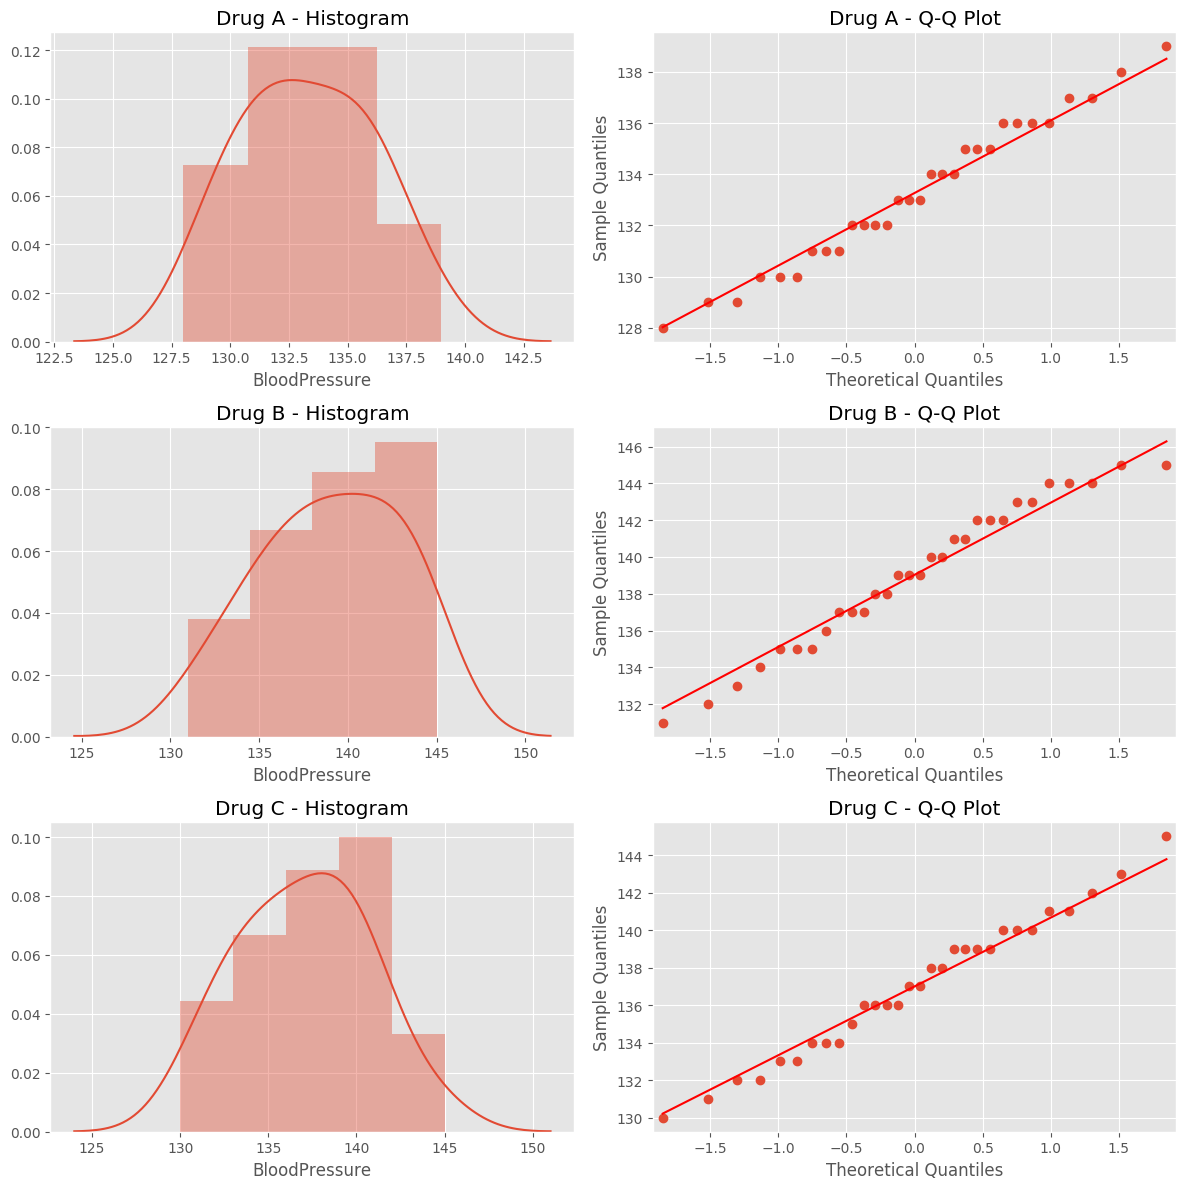

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
plt.style.use('ggplot')

fig, axes = plt.subplots(3, 2, figsize=(12, 12))

for i, group in enumerate(df['Drug'].unique()):
    data = df[df['Drug'] == group]['BloodPressure']
    
    # Histogram
    sns.distplot(data, kde=True, ax=axes[i, 0])
    axes[i, 0].set_title(f'{group} - Histogram')
    
    # QQ plot
    sm.qqplot(data, line='s', ax=axes[i, 1])
    axes[i, 1].set_title(f'{group} - Q-Q Plot')

plt.tight_layout()
plt.show()

**등분산성 검정**

1. Levene’s Test (Mean 기준)
	- 목적: 여러 그룹 간 분산이 동일한지(등분산성) 평가
	- 방법: 각 관측값에서 그룹의 **평균**을 뺀 절댓값의 분산을 비교
	- 특징: 정규성 가정을 완전히 요구하지 않기 때문에 비교적 유연
	- 평균 기준으로 그룹 중앙을 설정
    
2. Brown-Forsythe Test (Median 기준)
	- 목적: Levene 검정과 동일하게 등분산성 평가
	- 차이점: 평균 대신 **중앙값(median)** 을 사용하여 이상치(outliers)에 덜 민감
	- 추천 상황: 데이터에 이상치가 있거나 정규성이 약한 경우

In [13]:
from scipy.stats import levene

group_A = df[df['Drug'] == 'Drug A']['BloodPressure']
group_B = df[df['Drug'] == 'Drug B']['BloodPressure']
group_C = df[df['Drug'] == 'Drug C']['BloodPressure']

# Levene's test (mean 기준)
lev_stat, lev_p = levene(group_A, group_B, group_C)
print(f"\nLevene’s Test (Mean 기준): F = {lev_stat:.2f}, df = (2, {len(df)-3}), p = {lev_p:.3f}")

# Brown-Forsythe test (median 기준)
bf_stat, bf_p = levene(group_A, group_B, group_C, center='median')
print(f"Brown-Forsythe Test (Median 기준): F = {bf_stat:.2f}, df = (2, {len(df)-3}), p = {bf_p:.3f}")


Levene’s Test (Mean 기준): F = 1.74, df = (2, 87), p = 0.182
Brown-Forsythe Test (Median 기준): F = 1.74, df = (2, 87), p = 0.182


In [16]:
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm

model = ols('BloodPressure ~ C(Drug)', data=df).fit()
anova_results = anova_lm(model)

anova_results

,df,sum_sq,mean_sq,F,PR(>F)
C(Drug),2.0,513.266667,256.633333,20.172052,6.346112e-08
Residual,87.0,1106.833333,12.722222,NaN,NaN


- 유의미한 차이가 있음 -> 사후검정 가능

## 효과 크기 (Effect Size)
- 효과 크기: 독립변수가 종속변수에 얼마나 영향을 미쳤는지를 수치로 나타낸 지표
- 단순히 “유의미한 차이가 있다(p < 0.05)“는 것만으로는 실제 효과의 크기나 중요성을 알 수 없기 때문에, 효과 크기가 함께 해석되어야 한다.

1. η² (Eta Squared) : 전체 분산 중에서 독립변수가 설명하는 비율
2. η²p (Partial Eta Squared) : 부분 분산 중에서 독립변수가 설명하는 비율 (다요인 ANOVA에 주로 사용)
3. Cohen’s f² : 효과 크기를 상대적으로 보는 비율로, 회귀/분산분석의 보완적 지표

$η²$
- 0.01 => 작은 효과 (small)
- 0.06 => 중간 효과 (medium)
- 0.14 => 큰 효과 (large)


$Cohen’s f²$
- 0.02 => 약한 효과 (weak)
- 0.15 => 중간 효과 (moderate)
- 0.35 => 강한 효과 (strong)

In [17]:
# 제곱합 추출
ss_between = anova_results['sum_sq'][0]   # Drug 그룹 간 제곱합
ss_within = anova_results['sum_sq'][1]    # 잔차 제곱합
ss_total = ss_between + ss_within       # 총 제곱합

# 효과 크기 계산
eta_squared = ss_between / ss_total
partial_eta_squared = eta_squared  # 일원분산분석에서는 동일
cohens_f2 = eta_squared / (1 - eta_squared)

print("=== 효과 크기 (Effect Size) ===")
print(f"η² (Eta Squared): {eta_squared:.2f}")
print(f"Partial η²: {partial_eta_squared:.2f}")
print(f"Cohen's f²: {cohens_f2:.2f}")

=== 효과 크기 (Effect Size) ===
η² (Eta Squared): 0.32
Partial η²: 0.32
Cohen's f²: 0.46


**해석**
- η² = 0.32: 전체 종속변수의 분산 중 32%가 약물 종류(Drug)에 의해 설명된다는 의미. 즉, 어떤 약을 썼는지가 혈압에 미친 영향이 매우 크다고 볼 수 있음.

- Cohen’s f² = 0.46: 매우 큰 효과 크기로 분류되며, 통계적으로뿐만 아니라 실질적으로도 중요한 차이가 있음을 의미.

## 사후 검정(등분산, 샘플 수 동일) - Tukey HSD

In [20]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Tukey HSD 수행
tukey_result = pairwise_tukeyhsd(endog=df['BloodPressure'],
                                 groups=df['Drug'],
                                 alpha=0.05)

# 결과 출력
print(tukey_result) # print 꼭 해줘야함

Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
Drug A Drug B   5.7667    0.0  3.5707 7.9627   True
Drug A Drug C   3.7333 0.0003  1.5373 5.9293   True
Drug B Drug C  -2.0333 0.0755 -4.2293 0.1627  False
---------------------------------------------------


해석 : 사후검정 결과 약물 A와 B 그룹, 약물 A와 C 그룹에서 유의수준 0.05에서 귀무가설을 기각하여 평균 차이가 통계적으로 유의하다고 할 수 있다.

In [45]:
 # p-adj 는 조정된 p-value로서 유의수준 0.05 보다 적은 경우 reject True 로 판명되어 귀무가설을 기각하게 된다.

# 사후검정 예외 : Scheffé 검정 (보수적인 검정)
- Scheffé Test는 그룹 간 평균 차이를 분석할 때,**모든 가능한 선형 조합(linear combination)** 에 대해 안전하게 검정
- 일반적인 사후검정은 쌍(pairwise) 비교에만 집중하는 반면,**Scheffé 검정은 쌍 비교뿐만 아니라 모든 형태의 그룹 비교(예: A와 (B+C)의 평균 차이)** 에도 적용가능

- 비모수 상황, 정규성 미충족 시 적합하지 않음
- 보수적 접근이 필요한 연구 (ex: 의료, 정책 평가 등) 시 추천

In [ ]:
# 매우 보수적인 검정 : **1종 오류(Type I error)** 를 매우 잘 통제함
# 적합한 상황 : 많은 비교를 하거나, 모든 가능한 그룹 조합을 검정하고자 할 때 적합
# 단점 : 너무 보수적이라 2종 오류(Type II error) 가능성이 큼 → 민감도 낮음

In [26]:
from scipy.stats import f
from itertools import combinations

# 잔차 정보
MSE = anova_results.loc['Residual', 'mean_sq']
df_resid = anova_results.loc['Residual', 'df']

# --------------------
# 3. 그룹 정보
# --------------------
groups = df['Drug'].unique()
group_means = df.groupby('Drug')['BloodPressure'].mean()
group_sizes = df.groupby('Drug').size()

# --------------------
# 4. Scheffé 사후검정
# --------------------
alpha = 0.05
n_groups = len(groups)

# F 임계값 (Scheffé 방식)
F_critical = f.ppf(1 - alpha, n_groups - 1, df_resid) * (n_groups - 1)

# 결과 저장
results = []

for g1, g2 in combinations(groups, 2):
    m1, m2 = group_means[g1], group_means[g2]
    n1, n2 = group_sizes[g1], group_sizes[g2]
    
    mean_diff = m1 - m2
    se_diff = np.sqrt(MSE * (1/n1 + 1/n2))
    
    F_val = (mean_diff**2) / (se_diff**2)
    reject = F_val > F_critical

    results.append({
        'Group 1': g1,
        'Group 2': g2,
        'Mean Diff': round(mean_diff, 2),
        'F': round(F_val, 2),
        'Scheffé Critical': round(F_critical, 2),
        'Reject H0': reject
    })

# --------------------
# 5. 결과 출력
# --------------------
results_df = pd.DataFrame(results)
print("=== Scheffé 사후검정 결과 ===")
results_df

=== Scheffé 사후검정 결과 ===


,Group 1,Group 2,Mean Diff,F,Scheffé Critical,Reject H0
0,Drug A,Drug B,-5.77,39.21,6.2,True
1,Drug A,Drug C,-3.73,16.43,6.2,True
2,Drug B,Drug C,2.03,4.87,6.2,False


# Welch's 일원배치 분산분석 : 이분산성 일때

In [99]:
A = ['A0']*6 + ['A1']*6 + ['A3']*6 + ['A4']*6 
Y = [76,80, 78,79,83,74, 82,75,83,78,85, 80, 79, 87, 88,86,84,82, 81,74,76, 78,73,70]

df = pd.DataFrame({"X":A, "Y":Y})
df 

,X,Y
0,A0,76
1,A0,80
2,A0,78
3,A0,79
4,A0,83
5,A0,74
6,A1,82
7,A1,75
8,A1,83
9,A1,78


In [ ]:
# use_var = 'unequal' : 이분산성 가정이므로 

In [100]:
from statsmodels.stats.oneway import anova_oneway
oa = anova_oneway(data = df['Y'], groups = df['X'], use_var = 'unequal') # 이분산 가정이므로 unequal
print(f"검정통계량 : {oa.statistic:.3f}, 유의확률 : {oa.pvalue:.3f}")

# 귀무가설 : 모든 모집단의 평균이 동일하다.
# 대립가설 : 모든 모집단의 평균이 동일한 것은 아니다. 

# 귀무가설 기각하므로 적어도 한 집단의 모평균이 다르다고 말할 수 있다. = 모든 모집단의 평균이 동일하다고 말할 수 없다. -> 사후 검정 

검정통계량 : 6.019, 유의확률 : 0.011


In [105]:
import pingouin as pg
import pandas as pd

welch_result = pg.welch_anova(dv='Y', between='X', data=df)
welch_result

,Source,ddof1,ddof2,F,p-unc,np2
0,X,3,11.08,6.02,0.01,0.51


## 사후 검정 : 이분산성일 때 

In [103]:
# GamesHowell
from pingouin import pairwise_gameshowell
gw = pairwise_gameshowell(dv = 'Y',between = 'X', data = df)
gw

,A,B,mean(A),mean(B),diff,se,T,df,pval,hedges
0,A0,A1,78.33,80.50,-2.17,1.96,-1.11,9.81,0.68,-0.59
1,A0,A3,78.33,84.33,-6.00,1.89,-3.18,9.94,0.04,-1.70
2,A0,A4,78.33,75.33,3.00,2.04,1.47,9.58,0.49,0.78
3,A1,A3,80.50,84.33,-3.83,2.02,-1.89,9.96,0.29,-1.01
4,A1,A4,80.50,75.33,5.17,2.17,2.38,9.95,0.14,1.27
5,A3,A4,84.33,75.33,9.00,2.10,4.28,9.82,0.01,2.28


In [104]:
# 사후검정 결과 A0와 A3, A3와 A4 간의 모평균의 차이가 있는 것으로 확인된다. (pval이 0.05보다 작은 것들)

# 이원배치 분산분석 : 독립변수(범주형) 2개 이상

**귀무가설이 3개**
1. 
- 귀무가설 : 첫 번째 요인의 그룹 간 평균(요인 수준) 중에는 유의미한 차이가 없다. 
- 대립가설 : 첫 번째 요인의 그룹 간 평균(요인 수준) 중 적어도 하나는 유의미한 차이가 있다.

2.  
- 귀무가설 : 두 번째 요인의 그룹 간 평균(요인 수준)에는 유의미한 차이가 없다. 
- 대립가설 : 두 번째 요인의 그룹 간 평균(요인 수준) 중 적어도 하나는 유의미한 차이가 있다.
  
3. 
- 귀무가설 : 한 가지 요인은 다른 요인의 효과에 아무런 영향을 미치지 않는다. 
- 대립가설 : 한 요인이 다른 요인에 영향을 미칩니다.(교호작용이 존재한다.)

<조건>
1. 종속변인의 척도 수준은 계량적, 독립변인(요인)의 척도 수준은 명목형 변수
2. 독립성: 측정값은 독립적이어야 한다. 즉, 한 집단의 측정값이 다른 집단의 측정값에 영향을 받아서는 안 됩니다. 만약 그렇다면 **반복 측정 분산 분석**
3. 동질성: 각 군의 분산은 거의 동일해야 한다. 이는 **레벤 검정**으로 확인 .
4. 정규 분포: 그룹 내의 데이터는 정규 분포.

![Example](./Two-factor_ANOVA_formula.png)

In [1]:
import pandas as pd

# 데이터 정의
data = {
    "Attitude": [6, 4, 7, 9, 3, 4, 5, 6, 7, 5, 8, 3, 5, 8, 6, 3, 5, 9, 2, 3],
    "Studied": [
        "no", "no", "no", "no", "no",
        "yes", "yes", "yes", "yes", "yes",
        "no", "no", "no", "no", "no",
        "yes", "yes", "yes", "yes", "yes"
    ],
    "Gender": [
        "male", "male", "male", "male", "male",
        "male", "male", "male", "male", "male",
        "female", "female", "female", "female", "female",
        "female", "female", "female", "female", "female"
    ]
}

# DataFrame 생성
df = pd.DataFrame(data)

# 결과 확인
df

,Attitude,Studied,Gender
0,6,no,male
1,4,no,male
2,7,no,male
3,9,no,male
4,3,no,male
5,4,yes,male
6,5,yes,male
7,6,yes,male
8,7,yes,male
9,5,yes,male


In [2]:
import pandas as pd
import scipy.stats as stats
import numpy as np
from statsmodels.stats.diagnostic import lilliefors

# 그룹 레이블 생성
df['Group'] = df['Studied'] + '_' + df['Gender']

# 정규성 검정
for group in df['Group'].unique():
    data = df[df['Group'] == group]['Attitude']
    
    print(f"\n=== {group} ===")
    
    # Kolmogorov-Smirnov
    ks_stat, ks_p = stats.kstest(data, 'norm', args=(np.mean(data), np.std(data)))
    print(f"Kolmogorov-Smirnov: stat={ks_stat:.2f}, p={ks_p:.3f}")
    
    # Lilliefors (K-S 수정)
    lf_stat, lf_p = lilliefors(data)
    print(f"Lilliefors (K-S 수정): stat={lf_stat:.2f}, p={lf_p:.3f}")
    
    # Shapiro-Wilk
    shapiro_stat, shapiro_p = stats.shapiro(data)
    print(f"Shapiro-Wilk: stat={shapiro_stat:.2f}, p={shapiro_p:.3f}")


=== no_male ===
Kolmogorov-Smirnov: stat=0.20, p=0.961
Lilliefors (K-S 수정): stat=0.17, p=0.906
Shapiro-Wilk: stat=0.97, p=0.899

=== yes_male ===
Kolmogorov-Smirnov: stat=0.25, p=0.837
Lilliefors (K-S 수정): stat=0.24, p=0.479
Shapiro-Wilk: stat=0.96, p=0.814

=== no_female ===
Kolmogorov-Smirnov: stat=0.25, p=0.832
Lilliefors (K-S 수정): stat=0.23, p=0.551
Shapiro-Wilk: stat=0.91, p=0.468

=== yes_female ===
Kolmogorov-Smirnov: stat=0.31, p=0.615
Lilliefors (K-S 수정): stat=0.29, p=0.198
Shapiro-Wilk: stat=0.85, p=0.180


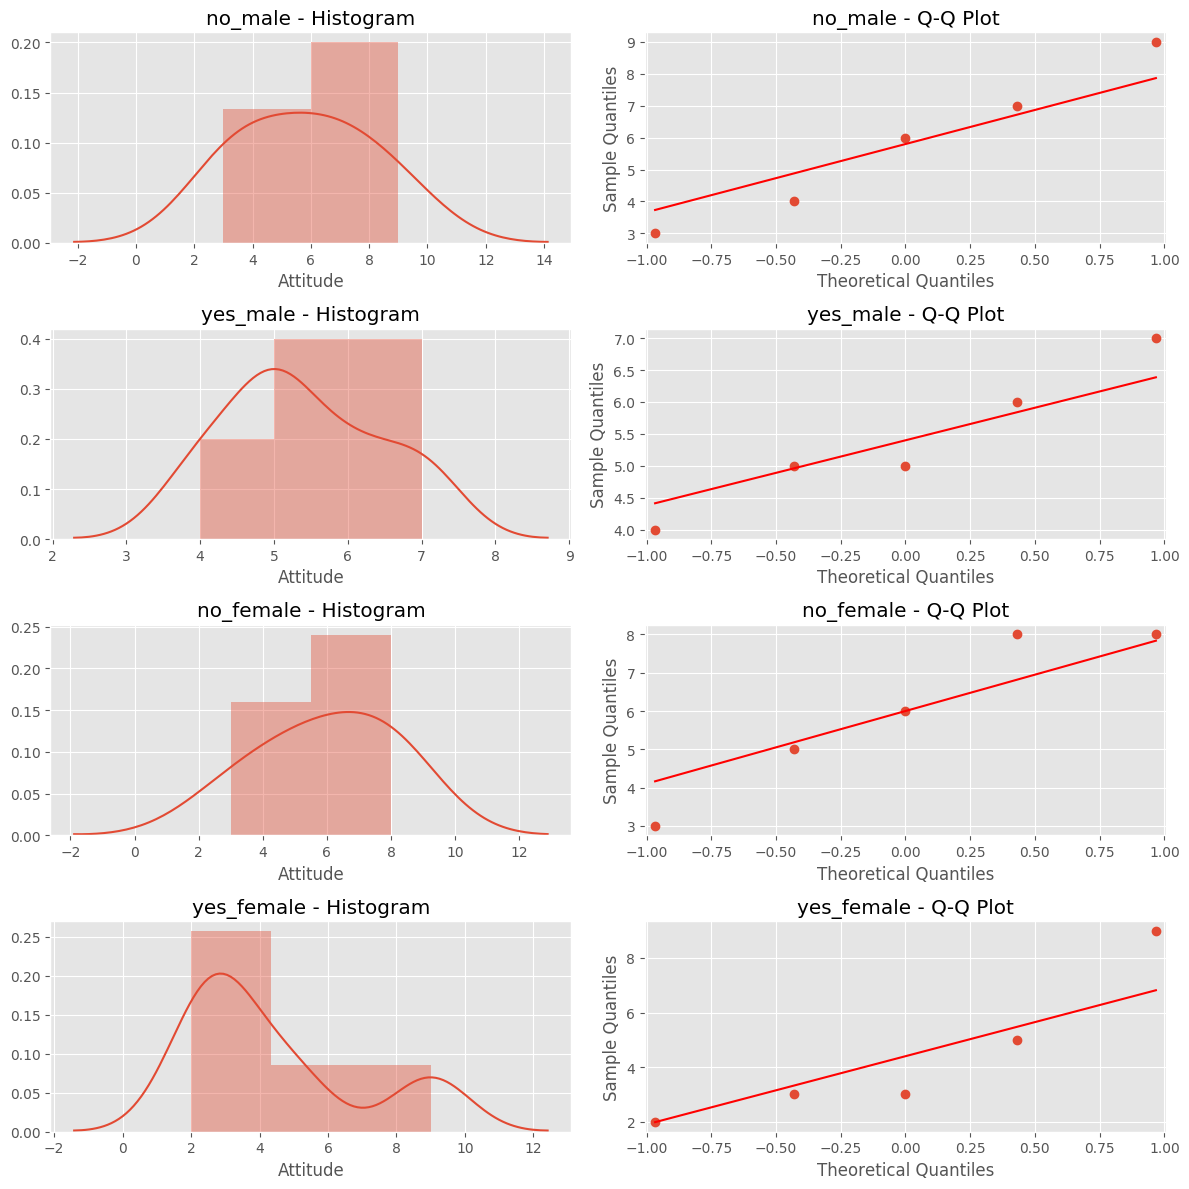

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.graphics.gofplots import qqplot

plt.style.use('ggplot')

# 고유 그룹 추출
groups = df['Group'].unique()

# 3행 2열 subplot 준비
fig, axes = plt.subplots(4, 2, figsize=(12, 12))
axes = axes.flatten()  # 인덱싱을 쉽게 하기 위해 1차원으로 변환

for i, group in enumerate(groups):
    data = df[df['Group'] == group]['Attitude']

    # 히스토그램 + KDE
    sns.distplot(data, kde=True, ax=axes[i*2])
    axes[i*2].set_title(f'{group} - Histogram')

    # Q-Q Plot
    sm.qqplot(data, line='s', ax=axes[i*2 + 1])
    axes[i*2 + 1].set_title(f'{group} - Q-Q Plot')

plt.tight_layout()
plt.show()

In [5]:
# 그룹별로 Attitude 리스트 분리
grouped_data = [group["Attitude"].values for name, group in df.groupby("Group")]
grouped_data

[array([8, 3, 5, 8, 6]),
 array([6, 4, 7, 9, 3]),
 array([3, 5, 9, 2, 3]),
 array([4, 5, 6, 7, 5])]

In [7]:
from scipy.stats import levene

# Levene's Test (Mean 기준)
levene_mean = levene(*grouped_data, center='mean')

# Brown-Forsythe Test (Median 기준)
levene_median = levene(*grouped_data, center='median')

# 결과 출력
print("=== Levene’s Test (Mean 기준) ===")
print(f"F-statistic: {levene_mean.statistic:.2f}")
print(f"df1: {len(grouped_data) - 1}, df2: {df.shape[0] - len(grouped_data)}")
print(f"p-value: {levene_mean.pvalue:.3f}")

print("\n=== Brown-Forsythe Test (Median 기준) ===")
print(f"F-statistic: {levene_median.statistic:.2f}")
print(f"df1: {len(grouped_data) - 1}, df2: {df.shape[0] - len(grouped_data)}")
print(f"p-value: {levene_median.pvalue:.3f}")

=== Levene’s Test (Mean 기준) ===
F-statistic: 0.98
df1: 3, df2: 16
p-value: 0.427

=== Brown-Forsythe Test (Median 기준) ===
F-statistic: 0.46
df1: 3, df2: 16
p-value: 0.715


# Type III ANOVA  : 교호작용이 있을 때 설계 

In [9]:
from statsmodels.formula.api import ols

# 범주형 변수로 변환 (중요!)
df['Studied'] = df['Studied'].astype('category')
df['Gender'] = df['Gender'].astype('category')

# 모델 정의 (with intercept)
model = ols('Attitude ~ C(Studied) * C(Gender)', data=df).fit()

# Type III ANOVA
anova_table = sm.stats.anova_lm(model, typ=3)

############### 없어도 됨 ###############################
# Partial eta squared 계산 함수
def compute_partial_eta_sq(anova_tbl):
    anova_tbl = anova_tbl.copy()
    anova_tbl['eta_sq_partial'] = anova_tbl[:-1]['sum_sq'] / (anova_tbl[:-1]['sum_sq']\
                                                              + anova_tbl.loc['Residual', 'sum_sq'])
    return anova_tbl

# 효과 크기 계산 포함된 ANOVA 결과
anova_with_eta = compute_partial_eta_sq(anova_table)

# 결과 출력
pd.options.display.float_format = '{:.2f}'.format
anova_with_eta

,sum_sq,df,F,PR(>F),eta_sq_partial
Intercept,180.00,1.00,37.31,0.00,0.70
C(Studied),6.40,1.00,1.33,0.27,0.08
C(Gender),0.10,1.00,0.02,0.89,0.00
C(Studied):C(Gender),1.80,1.00,0.37,0.55,0.02
Residual,77.20,16.00,NaN,NaN,NaN


In [10]:
anova_table

,sum_sq,df,F,PR(>F)
Intercept,180.00,1.00,37.31,0.00
C(Studied),6.40,1.00,1.33,0.27
C(Gender),0.10,1.00,0.02,0.89
C(Studied):C(Gender),1.80,1.00,0.37,0.55
Residual,77.20,16.00,NaN,NaN


모든 p-value > 0.05 귀무가설(차이가 없다) 모두 기각할 수 없음 -> 교호작용 없음, 주효과도 없음 

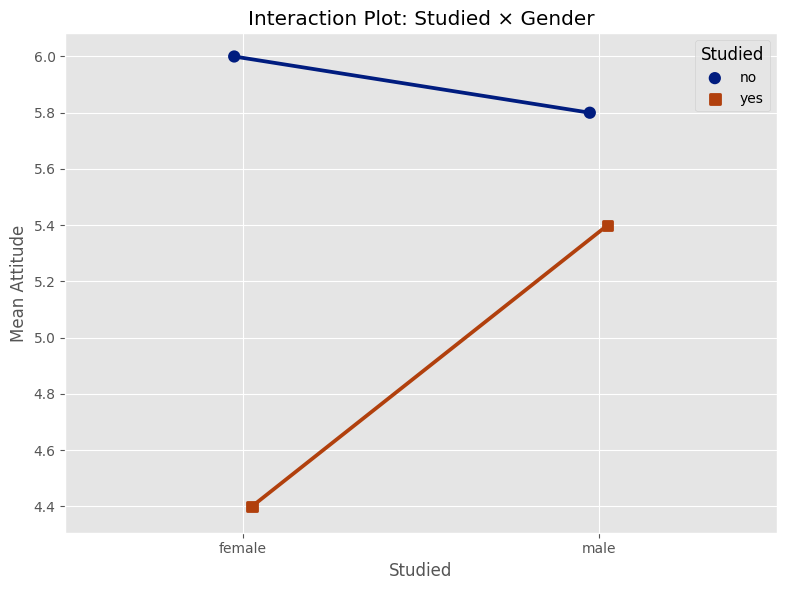

In [12]:
# 평균값 계산 (pivot table)
mean_df = df.groupby(['Studied', 'Gender'])['Attitude'].mean().reset_index()

# 시각화
plt.figure(figsize=(8, 6))
sns.pointplot(data=mean_df, x='Gender', y='Attitude', hue='Studied', 
              dodge=True, markers=['o', 's'], capsize=.1, errwidth=1, palette='dark')

plt.title('Interaction Plot: Studied × Gender')
plt.ylabel('Mean Attitude')
plt.xlabel('Studied')
plt.grid(True)
plt.tight_layout()
plt.show()

# 예외적으로 사후검정을 하는 경우 
- 이론적으로 특정 그룹 간 차이를 기대했고, p값은 유의하지 않지만 **효과 크기(η²)가 비교적 큼 (ex. η² > 0.14)**
- 데이터 수가 너무 작아서 검정력이 부족했을 가능성

In [14]:
import statsmodels.stats.multicomp as mc

# Bonferroni 사후검정 for Gender
comp_gender = mc.MultiComparison(df['Attitude'], df['Gender'])
posthoc_gender = comp_gender.allpairtest(stats.ttest_ind, method='bonf')
print("Bonferroni Post-hoc Test - Gender")
print(posthoc_gender[0])

Bonferroni Post-hoc Test - Gender
Test Multiple Comparison ttest_ind 
FWER=0.05 method=bonf
alphacSidak=0.05, alphacBonf=0.050
group1 group2  stat   pval  pval_corr reject
--------------------------------------------
female   male -0.414 0.6837    0.6837  False
--------------------------------------------


In [15]:
# Bonferroni 사후검정 for Studied
# 여기서는 Studied 변수가 eta squared(효과크기)가 상대적으로 조금 크기때문에 사후검정 실시
comp_studied = mc.MultiComparison(df['Attitude'], df['Studied'])
posthoc_studied = comp_studied.allpairtest(stats.ttest_ind, method='bonf')
print("\nBonferroni Post-hoc Test - Studied")
print(posthoc_studied[0])


Bonferroni Post-hoc Test - Studied
Test Multiple Comparison ttest_ind 
FWER=0.05 method=bonf
alphacSidak=0.05, alphacBonf=0.050
group1 group2  stat  pval  pval_corr reject
-------------------------------------------
    no    yes 1.062 0.3023    0.3023  False
-------------------------------------------


In [17]:
import pingouin as pg

# Bonferroni 사후검정
results = pg.pairwise_ttests(dv='Attitude',        # 종속변수
                         between='Group',      # 그룹
                         data=df, 
                         padjust='bonf',       # Bonferroni 보정
                         parametric=True)      # 정규성 및 등분산 가정

results
# p-unc 보면 됨

,Contrast,A,B,Paired,Parametric,T,dof,Tail,p-unc,p-corr,p-adjust,BF10,hedges
0,Group,no_female,no_male,False,True,0.14,8.00,two-sided,0.89,1.00,bonf,0.495,0.08
1,Group,no_female,yes_female,False,True,1.02,8.00,two-sided,0.34,1.00,bonf,0.672,0.58
2,Group,no_female,yes_male,False,True,0.56,8.00,two-sided,0.59,1.00,bonf,0.542,0.32
3,Group,no_male,yes_female,False,True,0.85,8.00,two-sided,0.42,1.00,bonf,0.614,0.49
4,Group,no_male,yes_male,False,True,0.34,8.00,two-sided,0.74,1.00,bonf,0.51,0.19
5,Group,yes_female,yes_male,False,True,-0.74,8.00,two-sided,0.48,1.00,bonf,0.583,-0.42


# 하나 더 

In [18]:
import pandas as pd

data = {
    'Treatment': ['A', 'A', 'B', 'B', 'A', 'A', 'B', 'B', 'A', 'A',
                  'B', 'B', 'A', 'A', 'B', 'B', 'A', 'A', 'B', 'B'],
    'Gender': ['Male', 'Female', 'Male', 'Female', 'Male', 'Female', 'Male', 'Female',
               'Male', 'Female', 'Male', 'Female', 'Male', 'Female', 'Male', 'Female',
               'Male', 'Female', 'Male', 'Female'],
    'BloodPressure': [130, 125, 140, 135, 128, 122, 138, 130,
                       132, 128, 144, 138, 135, 125, 140, 132,
                       128, 122, 138, 130]
}

df = pd.DataFrame(data)
df

,Treatment,Gender,BloodPressure
0,A,Male,130
1,A,Female,125
2,B,Male,140
3,B,Female,135
4,A,Male,128
5,A,Female,122
6,B,Male,138
7,B,Female,130
8,A,Male,132
9,A,Female,128


In [19]:
import scipy.stats as stats
import numpy as np
from statsmodels.stats.diagnostic import lilliefors

# 그룹 레이블 생성
df['Group'] = df['Treatment'] + '_' + df['Gender']

# 정규성 검정
for group in df['Group'].unique():
    data = df[df['Group'] == group]['BloodPressure']
    
    print(f"\n=== {group} ===")
    
    # Kolmogorov-Smirnov
    ks_stat, ks_p = stats.kstest(data, 'norm', args=(np.mean(data), np.std(data)))
    print(f"Kolmogorov-Smirnov: stat={ks_stat:.2f}, p={ks_p:.3f}")
    
    # Lilliefors (K-S 수정)
    lf_stat, lf_p = lilliefors(data)
    print(f"Lilliefors (K-S 수정): stat={lf_stat:.2f}, p={lf_p:.3f}")
    
    # Shapiro-Wilk
    shapiro_stat, shapiro_p = stats.shapiro(data)
    print(f"Shapiro-Wilk: stat={shapiro_stat:.2f}, p={shapiro_p:.3f}")


=== A_Male ===
Kolmogorov-Smirnov: stat=0.24, p=0.884
Lilliefors (K-S 수정): stat=0.21, p=0.692
Shapiro-Wilk: stat=0.90, p=0.391

=== A_Female ===
Kolmogorov-Smirnov: stat=0.26, p=0.821
Lilliefors (K-S 수정): stat=0.23, p=0.523
Shapiro-Wilk: stat=0.88, p=0.314

=== B_Male ===
Kolmogorov-Smirnov: stat=0.30, p=0.664
Lilliefors (K-S 수정): stat=0.30, p=0.169
Shapiro-Wilk: stat=0.83, p=0.146

=== B_Female ===
Kolmogorov-Smirnov: stat=0.23, p=0.892
Lilliefors (K-S 수정): stat=0.21, p=0.660
Shapiro-Wilk: stat=0.89, p=0.341


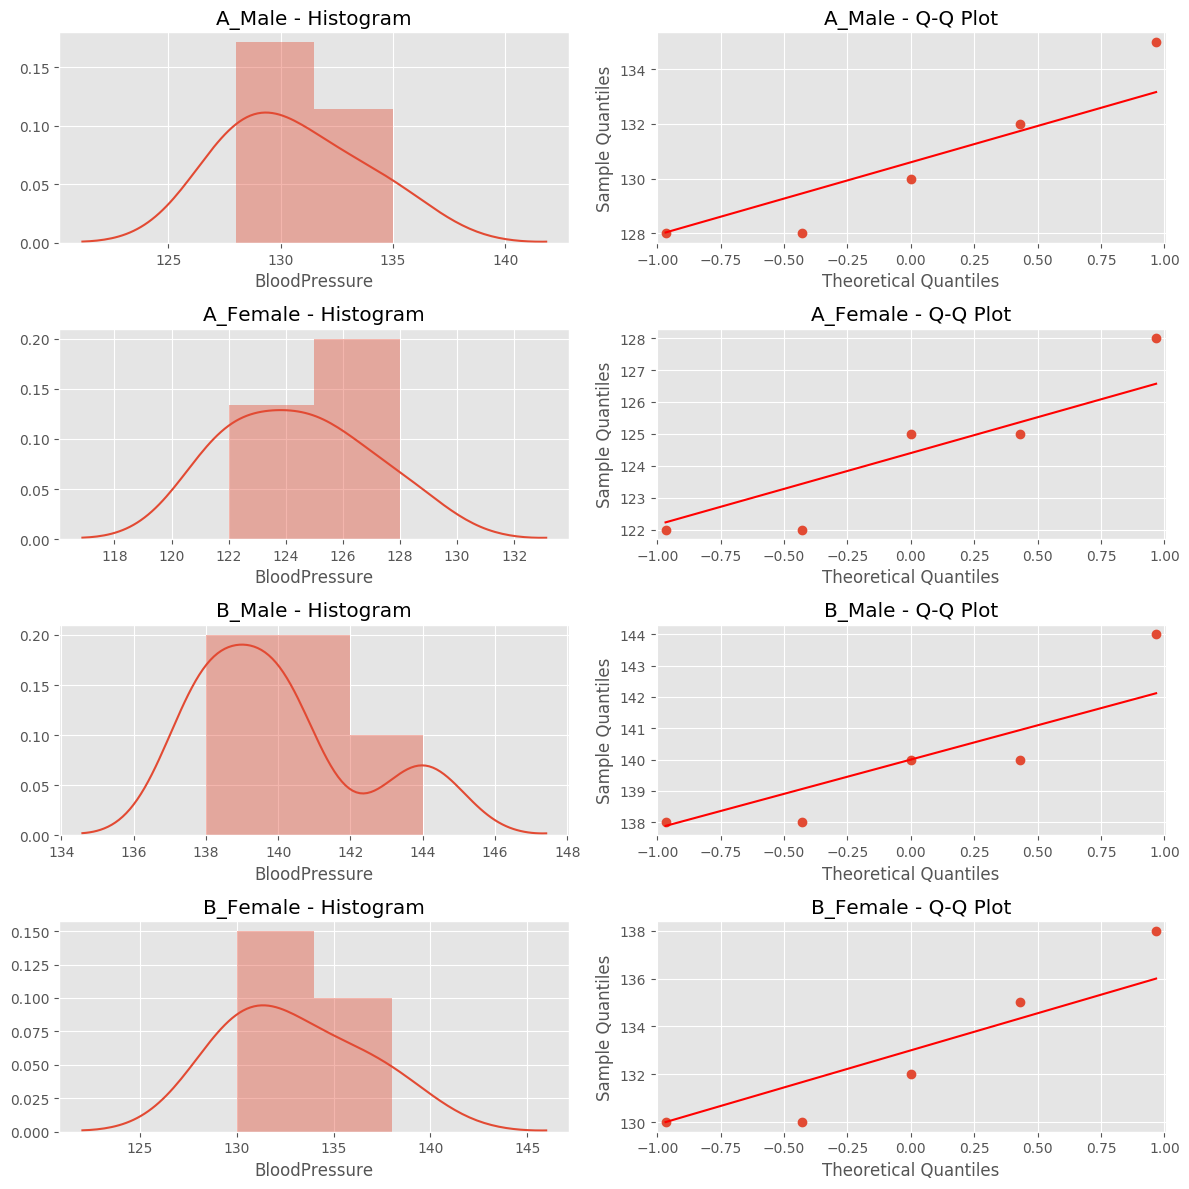

In [20]:
from statsmodels.graphics.gofplots import qqplot

plt.style.use('ggplot')

import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

# 고유 그룹 추출
groups = df['Group'].unique()

# 3행 2열 subplot 준비
fig, axes = plt.subplots(4, 2, figsize=(12, 12))
axes = axes.flatten()  # 인덱싱을 쉽게 하기 위해 1차원으로 변환

for i, group in enumerate(groups):
    data = df[df['Group'] == group]['BloodPressure']

    # 히스토그램 + KDE
    sns.distplot(data, kde=True, ax=axes[i*2])
    axes[i*2].set_title(f'{group} - Histogram')

    # Q-Q Plot
    sm.qqplot(data, line='s', ax=axes[i*2 + 1])
    axes[i*2 + 1].set_title(f'{group} - Q-Q Plot')

plt.tight_layout()
plt.show()

In [21]:
# 그룹별로 Attitude 리스트 분리
grouped_data = [group["BloodPressure"].values for name, group in df.groupby("Group")]
grouped_data

[array([125, 122, 128, 125, 122]),
 array([130, 128, 132, 135, 128]),
 array([135, 130, 138, 132, 130]),
 array([140, 138, 144, 140, 138])]

In [22]:
# Levene's Test (Mean 기준)
levene_mean = levene(*grouped_data, center='mean')

# Brown-Forsythe Test (Median 기준)
levene_median = levene(*grouped_data, center='median')

# 결과 출력
print("=== Levene’s Test (Mean 기준) ===")
print(f"F-statistic: {levene_mean.statistic:.2f}")
print(f"df1: {len(grouped_data) - 1}, df2: {df.shape[0] - len(grouped_data)}")
print(f"p-value: {levene_mean.pvalue:.3f}")

print("\n=== Brown-Forsythe Test (Median 기준) ===")
print(f"F-statistic: {levene_median.statistic:.2f}")
print(f"df1: {len(grouped_data) - 1}, df2: {df.shape[0] - len(grouped_data)}")
print(f"p-value: {levene_median.pvalue:.3f}")

=== Levene’s Test (Mean 기준) ===
F-statistic: 0.61
df1: 3, df2: 16
p-value: 0.616

=== Brown-Forsythe Test (Median 기준) ===
F-statistic: 0.29
df1: 3, df2: 16
p-value: 0.831


# ANOVA

In [23]:
# 범주형 변수로 변환 (중요!)
df['Treatment'] = df['Treatment'].astype('category')
df['Gender'] = df['Gender'].astype('category')

# 모델 정의 (with intercept)
model = ols('BloodPressure ~ C(Treatment) * C(Gender)', data=df).fit()

# Type II ANOVA : 교호작용 없으므로 
anova_table = sm.stats.anova_lm(model, typ=2)

############### 없어도 됨 ###############################
# Partial eta squared 계산 함수
def compute_partial_eta_sq(anova_tbl):
    anova_tbl = anova_tbl.copy()
    anova_tbl['eta_sq_partial'] = anova_tbl[:-1]['sum_sq'] / (anova_tbl[:-1]['sum_sq']\
                                                              + anova_tbl.loc['Residual', 'sum_sq'])
    return anova_tbl

# 효과 크기 계산 포함된 ANOVA 결과
anova_with_eta = compute_partial_eta_sq(anova_table)

# 결과 출력
pd.options.display.float_format = '{:.2f}'.format
anova_with_eta

,sum_sq,df,F,PR(>F),eta_sq_partial
C(Treatment),405.00,1.00,48.94,0.00,0.75
C(Gender),217.80,1.00,26.32,0.00,0.62
C(Treatment):C(Gender),0.80,1.00,0.10,0.76,0.01
Residual,132.40,16.00,NaN,NaN,NaN


교호작용이 p-value가 0.05보다 크다 -> 귀무가설 기각할 수 없음 = 교호작용 유의하지 않음 

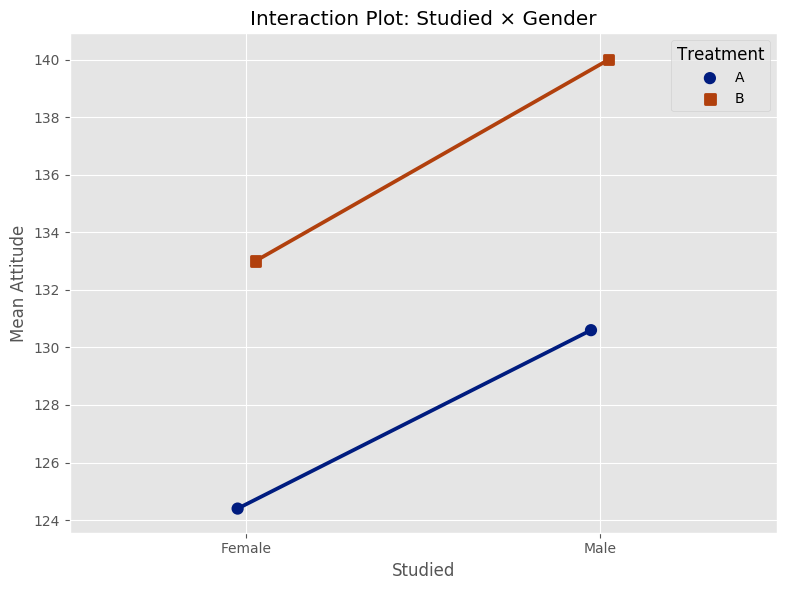

In [24]:
# 평균값 계산 (pivot table)
mean_df = df.groupby(['Treatment', 'Gender'])['BloodPressure'].mean().reset_index()

# 시각화
plt.figure(figsize=(8, 6))
sns.pointplot(data=mean_df, x='Gender', y='BloodPressure', hue='Treatment', 
              dodge=True, markers=['o', 's'], capsize=.1, errwidth=1, palette='dark')

plt.title('Interaction Plot: Studied × Gender')
plt.ylabel('Mean Attitude')
plt.xlabel('Studied')
plt.grid(True)
plt.tight_layout()
plt.show()

## 사후검정 

In [27]:
import statsmodels.stats.multicomp as mc

# Bonferroni 사후검정 for Gender
comp_gender = mc.MultiComparison(df['BloodPressure'], df['Treatment'])
posthoc_gender = comp_gender.allpairtest(stats.ttest_ind, method='bonf')
print("\nBonferroni Post-hoc Test - Treatment")
print(posthoc_gender[0])


Bonferroni Post-hoc Test - Treatment
Test Multiple Comparison ttest_ind 
FWER=0.05 method=bonf
alphacSidak=0.05, alphacBonf=0.050
group1 group2   stat   pval  pval_corr reject
---------------------------------------------
     A      B -4.5573 0.0002    0.0002   True
---------------------------------------------


In [28]:
# Bonferroni 사후검정 for Studied
comp_studied = mc.MultiComparison(df['BloodPressure'], df['Gender'])
posthoc_studied = comp_studied.allpairtest(stats.ttest_ind, method='bonf')
print("\nBonferroni Post-hoc Test - Gender")
print(posthoc_studied[0])


Bonferroni Post-hoc Test - Gender
Test Multiple Comparison ttest_ind 
FWER=0.05 method=bonf
alphacSidak=0.05, alphacBonf=0.050
group1 group2   stat   pval  pval_corr reject
---------------------------------------------
Female   Male -2.6989 0.0147    0.0147   True
---------------------------------------------


In [98]:
import pingouin as pg

results = pg.pairwise_ttests(dv='BloodPressure',        # 종속변수
                         between='Group',      # 그룹
                         data=df, 
                         padjust='bonf',       # Bonferroni 보정
                         parametric=True)      # 정규성 및 등분산 가정

results

,Contrast,A,B,Paired,Parametric,T,dof,Tail,p-unc,p-corr,p-adjust,BF10,hedges
0,Group,A_Female,A_Male,False,True,-3.57,8.00,two-sided,0.01,0.04,bonf,6.452,-2.04
1,Group,A_Female,B_Female,False,True,-4.50,8.00,two-sided,0.00,0.01,bonf,16.185,-2.57
2,Group,A_Female,B_Male,False,True,-9.95,8.00,two-sided,0.00,0.00,bonf,1237.402,-5.68
3,Group,A_Male,B_Female,False,True,-1.18,8.00,two-sided,0.27,1.00,bonf,0.74,-0.67
4,Group,A_Male,B_Male,False,True,-5.46,8.00,two-sided,0.00,0.00,bonf,40.394,-3.12
5,Group,B_Female,B_Male,False,True,-3.69,8.00,two-sided,0.01,0.04,bonf,7.289,-2.11


# 공분산분석 : 분산분석에 공변량을 추가하여 분산분석 모델을 확장 (통제)
- 공변량을 통제하여 독립변수의 순수한 영향을 검정 
### 공변량은 연속형 변수
- 예시 : 세 종류의 비만 치료제 간의 효과가 차이가 있는지 검정 가능, 비만은 스트레스와 밀접한 관련이 있다. 참여자들의 스트레스 수준을 사전에 측정하여 스트레스 수준을 통제하여 치료제로 인한 순수한 차이를 검정 
- 스트레스 수준이 일정하다는 가정하에 치료제 간의 차이가 있는 지 검정 (스트레스의 영향을 배제)

In [3]:
import pandas as pd
import numpy as np

np.random.seed(0)

# 집단 A: 평균 공부시간 5시간, 점수에 영향을 줌
group_A_hours = np.random.normal(5, 1, 20)
group_A_scores = 50 + 5 * group_A_hours + np.random.normal(0, 5, 20)

# 집단 B: 평균 공부시간 7시간
group_B_hours = np.random.normal(7, 1, 20)
group_B_scores = 55 + 5 * group_B_hours + np.random.normal(0, 5, 20)

# 데이터프레임 구성
df = pd.DataFrame({
    'Group': ['A'] * 20 + ['B'] * 20,
    'Hours': np.concatenate([group_A_hours, group_B_hours]),
    'Score': np.concatenate([group_A_scores, group_B_scores])
})

import statsmodels.api as sm
from statsmodels.formula.api import ols

# ANCOVA 모델: 종속변수 = Group(집단) + Hours(공변량)
model = ols('Score ~ C(Group) + Hours', data=df).fit()
anova_table = sm.stats.anova_lm(model, typ=2)

print("공분산분석(ANCOVA) 결과")
print(anova_table)

📊 공분산분석(ANCOVA) 결과
              sum_sq    df          F    PR(>F)
C(Group)   49.787135   1.0   1.894063  0.177017
Hours     853.731732   1.0  32.478698  0.000002
Residual  972.578226  37.0        NaN       NaN


# Multi-way ANOVA : 세개 이상의 범주형 독립변수가 하나의 연속형 종속변수에 미치는 영향을 분석하는 모수 통계 기법

- 주효과(Main Effect): 각 독립변수가 종속변수에 미치는 개별 영향
- 교호작용(Interaction Effect): 두 개 이상의 독립변수가 동시에 작용해서 나타나는 복합 효과
- 학생들의 **시험 점수(Score)**에 영향을 주는 요인을 분석하고자 한다. 다음 세 가지 독립변수를 고려한다:
1. 성별 (Gender): 남, 여
2. 학습 방법 (Method): 온라인, 오프라인
3. 학년 (Year): 1학년, 2학년


In [2]:
import pandas as pd
import numpy as np

np.random.seed(42)

n = 10  # 각 조합당 학생 수
groups = []

# 범주형 변수: Gender, Method, Year
for gender in ['Male', 'Female']:
    for method in ['Online', 'Offline']:
        for year in ['Year1', 'Year2']:
            for _ in range(n):
                groups.append({
                    'Gender': gender,
                    'Method': method,
                    'Year': year
                })

df = pd.DataFrame(groups)
# 종속변수: 시험 점수 생성
# 임의로 각 효과를 설정 (주효과 + 일부 교호작용)
score_base = 70
df['Score'] = (
    score_base
    + (df['Gender'] == 'Female') * 3    # 여학생 효과
    + (df['Method'] == 'Offline') * 5   # 오프라인 효과
    + (df['Year'] == 'Year2') * 2       # 2학년 효과
    + np.random.normal(0, 3, size=len(df))  # 오차항
)
df

,Gender,Method,Year,Score
0,Male,Online,Year1,71.490142
1,Male,Online,Year1,69.585207
2,Male,Online,Year1,71.943066
3,Male,Online,Year1,74.569090
4,Male,Online,Year1,69.297540
...,...,...,...,...
75,Female,Offline,Year2,82.465708
76,Female,Offline,Year2,80.261141
77,Female,Offline,Year2,79.102978
78,Female,Offline,Year2,80.275282


In [3]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

# 모델 정의 (교호작용 포함)
model = ols('Score ~ C(Gender) * C(Method) * C(Year)', data=df).fit()
anova_table = sm.stats.anova_lm(model, typ=2)

print("Three-way ANOVA 결과")
anova_table   

Three-way ANOVA 결과


,sum_sq,df,F,PR(>F)
C(Gender),254.723831,1.0,32.409030,2.529297e-07
C(Method),470.629640,1.0,59.879164,4.721121e-11
C(Year),34.819046,1.0,4.430098,3.880120e-02
C(Gender):C(Method),0.364260,1.0,0.046346,8.301576e-01
C(Gender):C(Year),34.318080,1.0,4.366359,4.018889e-02
C(Method):C(Year),4.982718,1.0,0.633961,4.285235e-01
C(Gender):C(Method):C(Year),30.088460,1.0,3.828216,5.427526e-02
Residual,565.895245,72.0,NaN,NaN


# 사후 분석 

In [8]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt

# 성별에 대한 사후분석
print("Gender 사후분석")
tukey_gender = pairwise_tukeyhsd(endog=df['Score'], groups=df['Gender'], alpha=0.05)
print(tukey_gender)

# 학습방법에 대한 사후분석
print("\n Method 사후분석")
tukey_method = pairwise_tukeyhsd(endog=df['Score'], groups=df['Method'], alpha=0.05)
print(tukey_method)

# 학년에 대한 사후분석
print("\n Year 사후분석")
tukey_year = pairwise_tukeyhsd(endog=df['Score'], groups=df['Year'], alpha=0.05)
print(tukey_year)

Gender 사후분석
Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
Female   Male  -3.5688 0.0001 -5.2715 -1.8661   True
----------------------------------------------------

 Method 사후분석
Multiple Comparison of Means - Tukey HSD, FWER=0.05 
 group1 group2 meandiff p-adj  lower   upper  reject
----------------------------------------------------
Offline Online  -4.8509   0.0 -6.3841 -3.3178   True
----------------------------------------------------

 Year 사후분석
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper reject
--------------------------------------------------
 Year1  Year2   1.3195 0.1617 -0.5401 3.179  False
--------------------------------------------------


# 다변량 분산분석(MANOVA) : 종속변수 2개  
- 하나 이상의 범주형 독립변수가 둘 이상의 종속변수(연속형)에 동시에 미치는 영향을 검정하는 모수 통계 기법 
- 예시 : 세가지 학습 전략(A,B,C)에 따라 수학 점수와 과학 점수가 동시에 영향을 받는가? 
- 귀무가설 : 모든 집단의 종속변수 평균이 같다 
- 대립가설 : 적어도 하나의 집단은 평균이 다르다

In [4]:
import pandas as pd
import numpy as np

np.random.seed(42)

# 그룹 A, B, C 각각 20명씩
group = ['A'] * 20 + ['B'] * 20 + ['C'] * 20

# 수학 점수: 그룹 A는 낮음, B 중간, C 높음
math_scores = np.concatenate([
    np.random.normal(70, 5, 20),
    np.random.normal(75, 5, 20),
    np.random.normal(80, 5, 20)
])

# 과학 점수: 그룹 A는 중간, B 높음, C 낮음
science_scores = np.concatenate([
    np.random.normal(75, 5, 20),
    np.random.normal(80, 5, 20),
    np.random.normal(70, 5, 20)
])

# 데이터프레임 생성
df = pd.DataFrame({
    'Group': group,
    'Math': math_scores,
    'Science': science_scores
})
df

,Group,Math,Science
0,A,72.483571,72.604129
1,A,69.308678,74.071705
2,A,73.238443,69.468325
3,A,77.615149,69.018967
4,A,68.829233,79.062629
5,A,68.829315,81.781200
6,A,77.896064,74.639949
7,A,73.837174,80.017664
8,A,67.652628,76.808180
9,A,72.712800,71.774401


In [11]:
from statsmodels.multivariate.manova import MANOVA

# 모델 정의
manova = MANOVA.from_formula('Math + Science ~ Group', data=df)

# 결과 출력
print(manova.mv_test())

                   Multivariate linear model
                                                                
----------------------------------------------------------------
       Intercept         Value   Num DF  Den DF  F Value  Pr > F
----------------------------------------------------------------
          Wilks' lambda   0.0065 2.0000 56.0000 4311.5678 0.0000
         Pillai's trace   0.9935 2.0000 56.0000 4311.5678 0.0000
 Hotelling-Lawley trace 153.9846 2.0000 56.0000 4311.5678 0.0000
    Roy's greatest root 153.9846 2.0000 56.0000 4311.5678 0.0000
----------------------------------------------------------------
                                                                
----------------------------------------------------------------
            Group          Value  Num DF  Den DF  F Value Pr > F
----------------------------------------------------------------
             Wilks' lambda 0.3098 4.0000 112.0000 22.3019 0.0000
            Pillai's trace 0.8380 4.0000 114.

Wilks’ lambda: 가장 많이 사용됨. 작을수록 집단 차이 큼  
Pillai’s trace, Hotelling-Lawley, Roy’s greatest root: 다른 검정 통계량 (보조 판단용)  
p-value	0.05보다 작으면 → 귀무가설 기각 → 집단 간 종속변수 차이 있음  

In [12]:
# Wilks’ lambda = 0.000, p < 0.001
# 귀무가설 기각 → 학습 방법에 따라 수학과 과학 점수가 동시에 유의미하게 다르다

# 어떤 그룹끼리 차이가 있는지는 사후분석(Tukey’s HSD 등)을 통해 확인

- 우리는 종속변수가 2개니까 다음 2가지를 각각 분리해서 분석
	1. Math 점수에 대한 그룹 간 차이
	2. Science 점수에 대한 그룹 간 차이

In [14]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt

# 수학 점수에 대한 사후분석
print("Math 점수에 대한 Tukey HSD")
tukey_math = pairwise_tukeyhsd(endog=df['Math'], groups=df['Group'], alpha=0.05)
print(tukey_math)

# 과학 점수에 대한 사후분석
print("\nScience 점수에 대한 Tukey HSD")
tukey_science = pairwise_tukeyhsd(endog=df['Science'], groups=df['Group'], alpha=0.05)
print(tukey_science)

Math 점수에 대한 Tukey HSD
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj  lower   upper  reject
---------------------------------------------------
     A      B   4.5266  0.008 1.0307  8.0225   True
     A      C   10.723    0.0 7.2271 14.2189   True
     B      C   6.1964 0.0002 2.7005  9.6923   True
---------------------------------------------------

Science 점수에 대한 Tukey HSD
 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower    upper  reject
-----------------------------------------------------
     A      B   5.0376 0.0044   1.3882   8.687   True
     A      C  -4.6219 0.0096  -8.2713 -0.9725   True
     B      C  -9.6595    0.0 -13.3089 -6.0101   True
-----------------------------------------------------


In [ ]:
# reject = True → 유의한 차이가 있다는 의미